# MTCG: Multi-Template Computational Graph for Traffic Demand Flow Estimation

**Melbourne Network — Results Visualization**

**Authors:**
- Xin (Bruce) Wu, Department of Civil and Environmental Engineering, Villanova University, USA
- Feng Shao, School of Mathematics, China University of Mining and Technology, China

**Contact:** xwu03@villanova.edu

---

MIT License

Copyright (c) 2026 Xin (Bruce) Wu, Feng Shao

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

# MTCG Results Visualization — Melbourne Network

This notebook generates publication figures from the MTCG estimation results.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Loss Curves

Plot training and test loss trajectories over epochs.

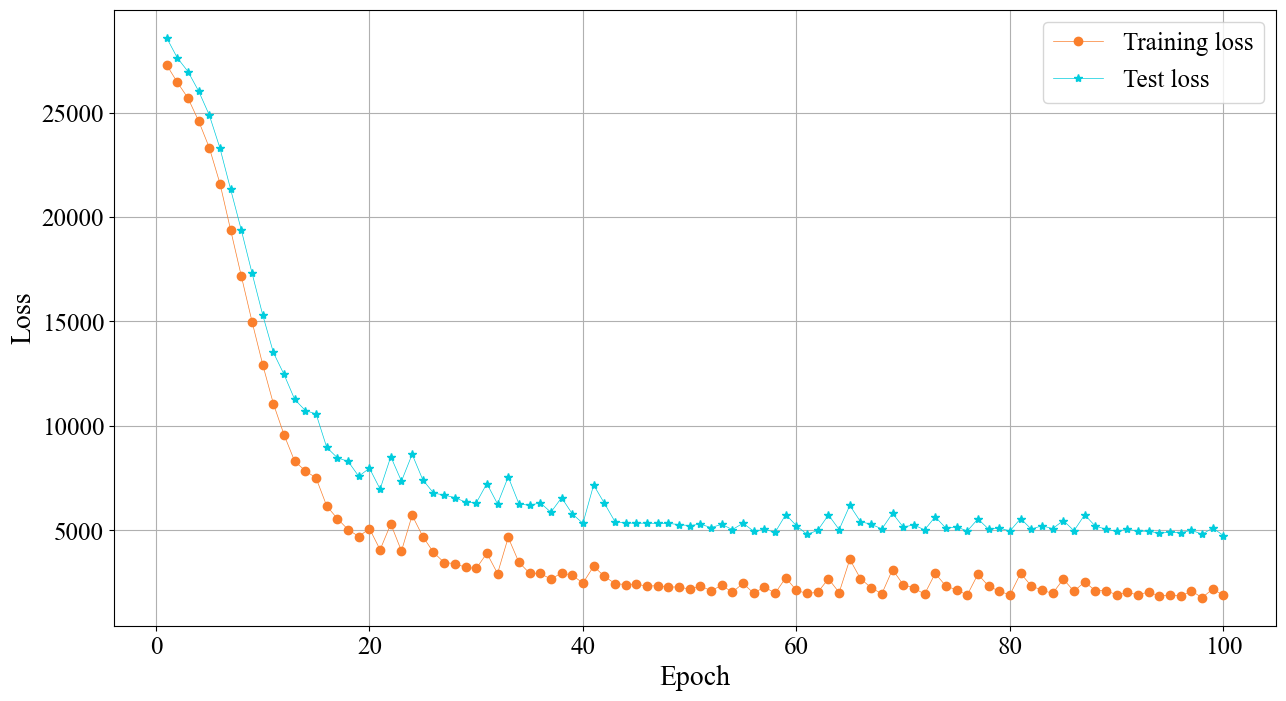

In [2]:
# Loss
x = np.arange(1,101)  # x-axis data
loss_train = pd.read_excel('loss_train.xlsx').values
loss_test = pd.read_excel('loss_test.xlsx').values

plt.rc('font',family='Times New Roman')

plt.figure(figsize=(15, 8))
# mpl.rcParams['font.family'] = 'DejaVu Serif'
# Plot line chart
plt.plot(x, loss_train, color="#FA7F2C", linewidth=0.5, label='Training loss', marker='o')
plt.plot(x, loss_test, color='#00CCDD', linewidth=0.5, label='Test loss', marker='*')

# Set legend, title, and axis labels
plt.legend()
# plt.title('Two Lines Chart')
# plt.xlabel('Epoch', fontsize=20)
# plt.ylabel('Total loss', fontsize=20)

# Adjust parameters (optional)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)  # Show grid lines

legend = plt.legend(prop={'size': 18})  # Set legend font size

plt.xlabel('Epoch', fontsize=20)
plt.ylabel('Loss', fontsize=20)

plt.savefig('Figures/loss.png',dpi=300, pad_inches=0.05)

# Show figure
plt.show()

In [3]:
# theta
theta = pd.read_csv('theta2.csv')
theta = theta.values
theta = theta.reshape([-1])
theta.shape

(30040,)

In [4]:
theta = theta * 10000

## 2. Value of Time Distribution

Visualize the estimated value-of-time (VOT) distribution and compare with Melbourne average wage data.

C:\Users\zhao\AppData\Local\Temp\ipykernel_89524\3781050284.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(theta, shade=True, color='grey', label='PDF', clip_on=False)


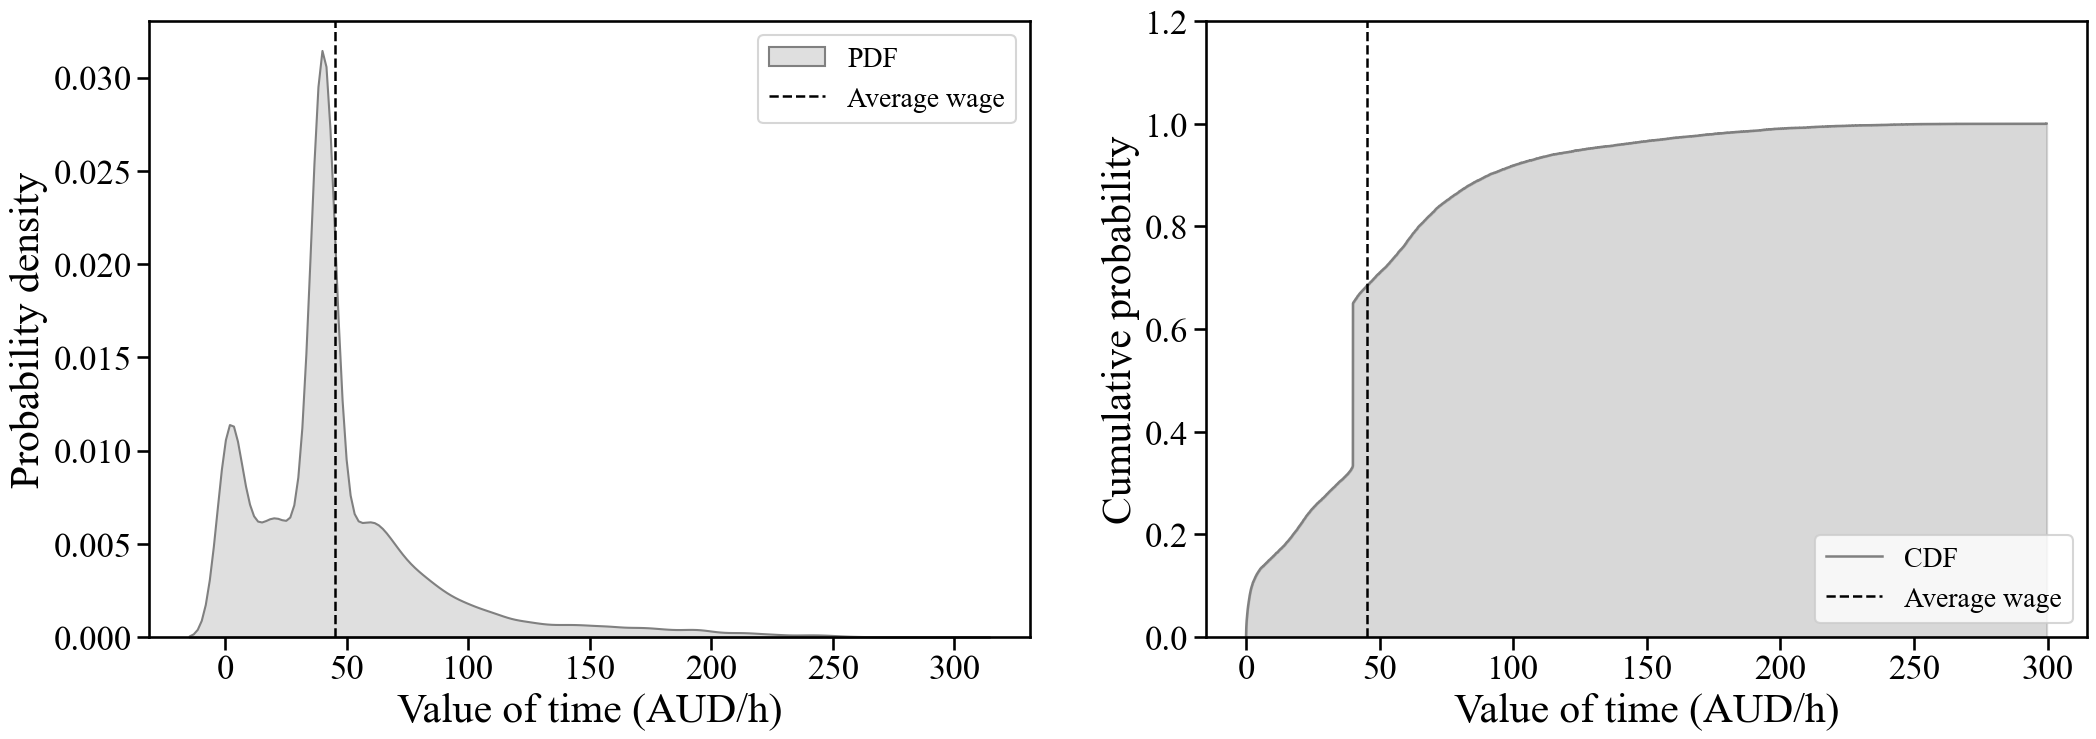

In [13]:
# plt.rc('font',family='Times New Roman')

plt.rc('font',family='Times New Roman')

# mpl.rcParams['font.family'] = 'DejaVu Serif'
# Set figure size and font size
fig = plt.figure(figsize=(25, 8))
plt.rcParams.update({'font.size': 10})

# Set Seaborn plot style and font scaling
sns.set_context("talk", font_scale=0.5, rc={"lines.linewidth": 1.8})

# Add first subplot
axes1 = fig.add_subplot(1, 2, 1)
sns.kdeplot(theta, shade=True, color='grey', label='PDF', clip_on=False)
axes1.axvline(45.19, color='black', linestyle='--', label='Average wage')  # Add vertical line
axes1.set_xlabel('Value of time', fontsize=30)
axes1.set_ylabel('Probability density', fontsize=30)
axes1.tick_params(axis='both', labelsize=25)
axes1.legend(loc='upper right', fontsize=20)  # Add and position legend
# --- subplot 1 ---
axes1.set_xlabel('Value of time (AUD/h)', fontsize=30)

# Add second subplot
axes2 = fig.add_subplot(1, 2, 2)

plt.rcParams.update({'font.size':5})
sns.set_context("talk",font_scale=0.5,rc={"lines.linewidth":1.8})
ax2 = sns.ecdfplot(theta,color='grey', label='CDF')

l1 = ax2.lines[0]
x1 = l1.get_xydata()[:,0]
y1 = l1.get_xydata()[:,1]
ax2.fill_between(x1,y1, color="grey", alpha=0.3)

# axes2.fill_between(x, y, color="grey", alpha=0.3)
axes2.axvline(45.19, color='black', linestyle='--', label='Average wage')  # Add vertical line

axes2.set_xlabel('Value of time', fontsize=30)
axes2.set_ylabel('Cumulative probability', fontsize=30)
axes2.tick_params(axis='both', labelsize=25)
axes2.set_ylim([0, 1.2])
axes2.legend(loc='lower right', fontsize=20)  # Add and position legend
# --- subplot 2 ---
axes2.set_xlabel('Value of time (AUD/h)', fontsize=30)

plt.savefig('Figures/PDF and CDF.jpg',dpi=300, pad_inches=0.05)

# Show figure
plt.show()

In [6]:
# estimation
est = pd.read_csv("estimation2.csv")
est

,0,1,2,3
0,30012.100,20399.0,91695.150,96076.0
1,31372.690,21546.0,95500.984,108958.0
2,34037.816,22804.0,103532.700,116355.0
3,35871.480,22314.0,108331.016,117743.0
4,37207.210,28785.0,111128.170,116901.0
5,38517.477,28766.0,113720.320,115800.0
6,38097.504,27954.0,110621.305,112795.0
7,37458.367,27625.0,106705.484,110604.0
8,37683.050,20789.0,105638.260,104375.0
9,36978.110,19262.0,101412.150,104415.0


In [7]:
lf_e = est.iloc[:,2].values
lf_g = est.iloc[:,3].values
d_e = est.iloc[:,0].values
d_g = est.iloc[:,1].values

## 3. Attention Weights

Visualize template attention weights across timesteps, showing how the model blends templates over time.

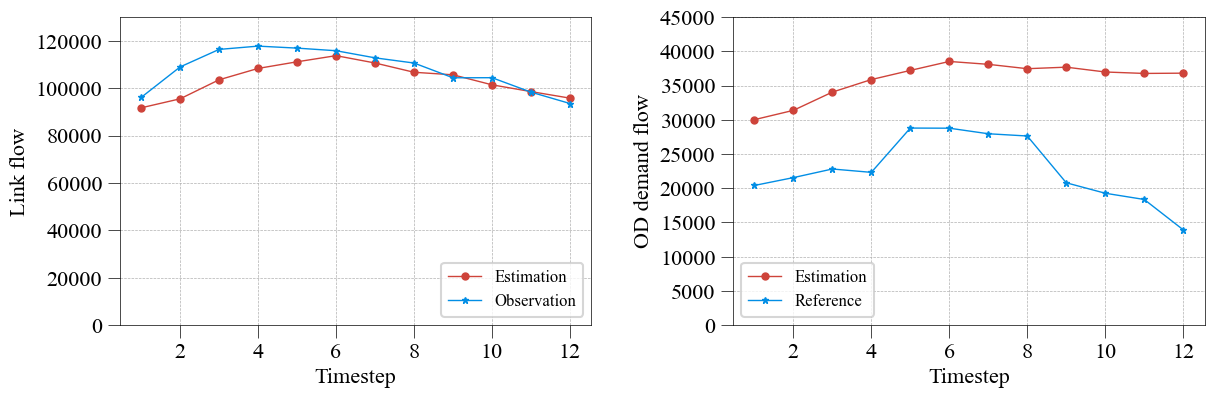

In [8]:
x = np.arange(1,13)  # x-axis data

fig = plt.figure()
fig.set_size_inches(14, 4)
plt.rcParams.update({
    'lines.linewidth': 0.5,  # Set default line width
    'axes.linewidth': 0.5   # Set axis border width
})

plt.rc('font', family='Times New Roman')
# mpl.rcParams['font.family'] = 'DejaVu Serif'
# First subplot
axes = fig.add_subplot(1, 2, 1)
plt.plot(x, lf_e, color='#CE433A', linewidth=1, label='Estimation', marker='o', markersize=5)
plt.plot(x, lf_g, color='#028EE5', linewidth=1, label='Observation', marker='*', markersize=5)
plt.legend(fontsize=12, loc='lower right')
plt.xlabel('Timestep', fontsize=16)
plt.ylabel('Link flow', fontsize=16)
# Adjust x/y axis tick width
plt.tick_params(axis='both', which='major', width=0.5)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 130000)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Second subplot
axes = fig.add_subplot(1, 2, 2)
plt.plot(x, d_e, color='#CE433A', linewidth=1, label='Estimation', marker='o', markersize=5)
plt.plot(x, d_g, color='#028EE5', linewidth=1, label='Reference', marker='*', markersize=5)
plt.legend(fontsize=12)
plt.xlabel('Timestep', fontsize=16)
plt.ylabel('OD demand flow', fontsize=16)
# Adjust x/y axis tick width
plt.tick_params(axis='both', which='major', width=0.5)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 45000)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjust horizontal spacing between subplots
fig.subplots_adjust(wspace=0.3)

plt.savefig('Figures/tend_pred.png',dpi=300, bbox_inches='tight', pad_inches=0.1) 

# Show figure
plt.show()

In [9]:
att = pd.read_csv('att.csv')
att

,0,1,2
0,0.451060,0.307769,0.241171
1,0.462971,0.232252,0.304776
2,0.464842,0.086681,0.448477
3,0.476088,0.017691,0.506221
4,0.462179,0.003728,0.534093
5,0.442251,0.012080,0.545669
6,0.406400,0.134476,0.459124
7,0.354746,0.271816,0.373438
8,0.321968,0.367079,0.310954
9,0.278822,0.504011,0.217167


In [10]:
att1 = att.iloc[:6,:].values.T
att1

array([[0.45106   , 0.46297148, 0.46484238, 0.47608778, 0.4621789 ,
        0.44225138],
       [0.3077695 , 0.232252  , 0.08668066, 0.01769148, 0.00372826,
        0.01207979],
       [0.24117051, 0.30477646, 0.4484769 , 0.50622076, 0.5340929 ,
        0.5456688 ]])

In [11]:
att2 = att.iloc[6:,:].values.T
att2

array([[0.40639997, 0.35474634, 0.32196772, 0.27882165, 0.24309076,
        0.18965106],
       [0.13447592, 0.27181572, 0.36707866, 0.50401115, 0.61474836,
        0.71779406],
       [0.45912418, 0.37343797, 0.31095362, 0.21716721, 0.14216094,
        0.09255481]])

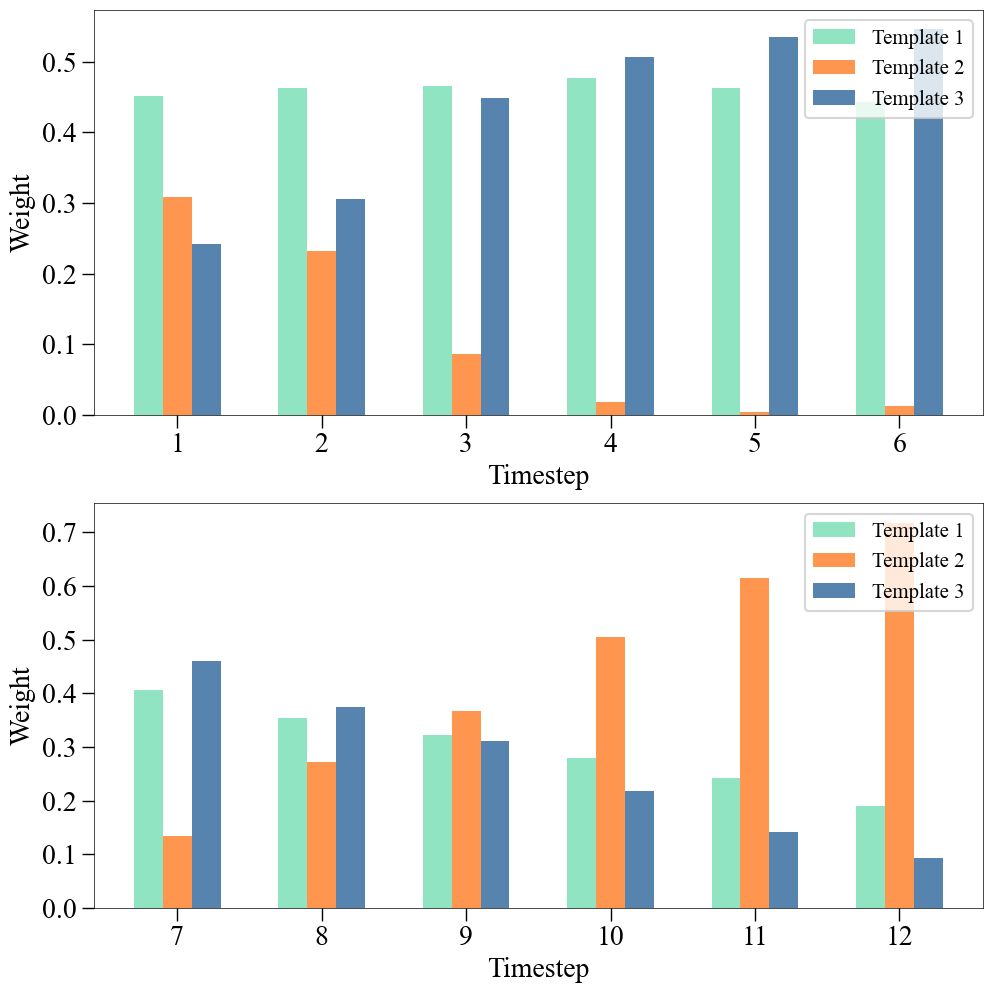

In [12]:
fig = plt.figure()
fig.set_size_inches(10, 10)
plt.rcParams.update({
    'lines.linewidth': 0.5,  # Set default line width
    'axes.linewidth': 0.5   # Set axis border width
})

plt.rc('font', family='Times New Roman')
# mpl.rcParams['font.family'] = 'DejaVu Serif'
# First subplot
################
# Define the data
axes = fig.add_subplot(2, 1, 1)

group1 = att1[0,:]
group2 = att1[1,:]
group3 = att1[2,:]

# Set the positions of the bars on the x-axis
x = np.arange(len(group1))

# Set the width of the bars
width = 0.2

# Create the bar chart
plt.bar(x - 1.0*width, group1, width=width, label='Template 1', color='#90e4c1')
plt.bar(x, group2, width=width, label='Template 2', color='#ff964f')
plt.bar(x + 1.0*width, group3, width=width, label='Template 3', color='#5684ae')

# Add labels, title, and legend
plt.xlabel('Timestep',fontsize=20)
plt.ylabel('Weight',fontsize=20)
# plt.title('Bar Chart')
plt.xticks(x, np.arange(1,7))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.legend(prop={'size': 15}, loc='upper right')
plt.legend(prop={'size': 15}, loc='upper right')


plt.tick_params(axis='both', which='major', width=1)
##########

# Second subplot
################
# Define the data
axes = fig.add_subplot(2, 1, 2)

group1 = att2[0,:]
group2 = att2[1,:]
group3 = att2[2,:]

# Set the positions of the bars on the x-axis
x = np.arange(len(group1))

# Set the width of the bars
width = 0.2

# Create the bar chart
plt.bar(x - 1.0*width, group1, width=width, label='Template 1', color='#90e4c1')
plt.bar(x, group2, width=width, label='Template 2', color='#ff964f')
plt.bar(x + 1.0*width, group3, width=width, label='Template 3', color='#5684ae')

# Add labels, title, and legend
plt.xlabel('Timestep',fontsize=20)
plt.ylabel('Weight',fontsize=20)
# plt.title('Bar Chart')
plt.xticks(x, np.arange(7,13))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.legend(prop={'size': 15}, loc='upper right')

plt.tick_params(axis='both', which='major', width=1)
plt.legend(prop={'size': 15}, loc='upper right')

##########

plt.tight_layout()

plt.savefig('Figures/weight.png',dpi=300, bbox_inches='tight', pad_inches=0.1) 

# Show figure
plt.show()